In [ ]:
!pip install google-play-scraper

In [ ]:
from google_play_scraper import reviews, Sort
import pandas as pd

app_id = 'app.bpjs.mobile'
jumlah_data = 20000

result, continuation_token = reviews(
    app_id, lang='id', country='id', sort=Sort.NEWEST,
    count=jumlah_data
)

data = []

for r in result:
    data.append({
        'review_id': r['reviewId'], 'user_name': r['userName'],
        'rating': r['score'], 'review_text': r['content'],
        'date': r['at'],
    })

df = pd.DataFrame(data)

df.to_csv('scraper_ulasan_jkn.csv', index=False, encoding='utf-8-sig')

print("Data komentar berhasil disimpan ke scraper_ulasan_jkn.csv")


Data komentar berhasil disimpan ke scraper_ulasan_jkn.csv


In [ ]:
print(df.columns)

Index(['review_id', 'user_name', 'rating', 'review_text', 'date'], dtype='object')


In [ ]:
print(len(df))

NameError: name 'df' is not defined

# Jalankan sekaligus


In [ ]:
!pip install Sastrawi

# Download tokenizer NLTK (cukup sekali)
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 14.3 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

**Preprocessing**

 PREPROCESSING DATA KOMENTAR GOOGLE PLAYSTORE (MOBILE JKN)

Tahapan:
1. Cleaning
2. Normalisasi
3. Tokenizing
4. Stemming
5. Stopword Removal

In [ ]:
import pandas as pd
import re
import string
import nltk

from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# LOAD DATA CSV hasil scraping dari Google Play Store
df = pd.read_csv("scraper_ulasan_jkn.csv")

# Pastikan kolom review bertipe string agar tidak error
df['review_text'] = df['review_text'].astype(str)

# CLEANING
def cleaning(text):
    text = text.lower()
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'\d+', '', text)

     # hapus emoticon
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "]+",
        flags=re.UNICODE
    )
    text = emoji_pattern.sub(r'', text)

    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaning'] = df['review_text'].apply(cleaning)

# NORMALISASI
kamus_df = pd.read_excel("kamuskatabaku.xlsx")

kamus_normalisasi = dict(zip(kamus_df['tidak_baku'], kamus_df['kata_baku']))

def normalisasi(text):
    words = text.split()
    normalized_words = [kamus_normalisasi.get(word, word) for word in words]
    return ' '.join(normalized_words)

df['normalisasi'] = df['cleaning'].apply(normalisasi)

# TOKENIZING
df['tokenizing'] = df['normalisasi'].apply(word_tokenize)

# STEMMING
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['stemming'] = df['tokenizing'].apply(stemming)

# STOPWORD REMOVAL
stopword_df = pd.read_excel("stopwordID.xlsx")

# stopwords = set(stopword_df['term'].astype(str).tolist())
stopwords = set(stopword_df['term'].astype(str).str.strip().tolist())
def stopword_removal(tokens):
    return [word for word in tokens if word not in stopwords]

df['stopword_removal'] = df['stemming'].apply(stopword_removal)

# HASIL AKHIR PREPROCESSING
df['hasil_preprocessing'] = df['stopword_removal'].apply(lambda x: ' '.join(x))

# SIMPAN KE FILE CSV
df.to_csv("hasil_preprocessing_jkn_uji_01.csv", index=False, encoding="utf-8-sig")
print("Preprocessing selesai. Data disimpan ke 'hasil_preprocessing_jkn.csv'")


Preprocessing selesai. Data disimpan ke 'hasil_preprocessing_jkn.csv'


In [ ]:
df['hasil_preprocessing'].head(5)


,hasil_preprocessing
0,layak hadir benerin keluh susah lupa
1,sungguh bantu
2,proses
3,benah antri tunggu wifi stabil susah cuman ber...
4,eror


**Pelabelan Berdasarkan Rating**

In [ ]:
import pandas as pd

# LOAD DATA hasil preprocessing
df = pd.read_csv("hasil_preprocessing_jkn_uji_01.csv")

# Memastikan kolom teks tidak kosong
df = df.dropna(subset=['hasil_preprocessing'])
df = df[df['hasil_preprocessing'].str.strip() != '']
df['hasil_preprocessing'] = df['hasil_preprocessing'].astype(str).str.lower()

# FUNGSI SENTIMEN BERDASARKAN RATING
def label_sentiment_by_rating(rating):
    if rating >= 4:
        return 'positif'
    elif rating == 3:
        return 'netral'
    else:
        return 'negatif'

# TERAPKAN PELABELAN
nama_kolom_rating = 'rating'

# Pastikan tipe data kolom rating adalah angka (numeric) agar tidak error saat dihitung
df[nama_kolom_rating] = pd.to_numeric(df[nama_kolom_rating], errors='coerce')

df = df.dropna(subset=[nama_kolom_rating])

df['label_sentimen'] = df[nama_kolom_rating].apply(label_sentiment_by_rating)

# CEK HASIL & SIMPAN
print("\nDistribusi Sentimen Berdasarkan Rating:")
print(df['label_sentimen'].value_counts())

# Menampilkan 5 sampel data untuk memastikan label sudah benar
print("\nSampel Hasil Pelabelan:")
print(df[[nama_kolom_rating, 'label_sentimen', 'hasil_preprocessing']].head())

# Menyimpan ke file baru
df.to_csv("data_berlabel_jkn_uji_01.csv", index=False, encoding='utf-8-sig')

print("\nProses selesai! Data berhasil dilabeli dan disimpan ke 'data_berlabel_jkn_uji_01.csv'")


Distribusi Sentimen Berdasarkan Rating:
label_sentimen
positif    11686
negatif     6299
netral       744
Name: count, dtype: int64

Sampel Hasil Pelabelan:
   rating label_sentimen                                hasil_preprocessing
0       1        negatif               layak hadir benerin keluh susah lupa
1       5        positif                                      sungguh bantu
2       2        negatif                                             proses
3       1        negatif  benah antri tunggu wifi stabil susah cuman ber...
4       5        positif                                               eror

Proses selesai! Data berhasil dilabeli dan disimpan ke 'data_berlabel_jkn_uji_01.csv'


**TF IDF dari hasil pelabelan**

In [ ]:
import pandas as pd
import math

# LOAD DATA HASIL PELABELAN
df = pd.read_csv("data_berlabel_jkn_uji_01.csv")

# Ambil hanya kolom hasil_preprocessing
df = df[['hasil_preprocessing']]

# Hapus data kosong
df = df.dropna()
df = df[df['hasil_preprocessing'].str.strip() != '']

# Pastikan string
df['hasil_preprocessing'] = df['hasil_preprocessing'].astype(str)

print("Jumlah dokumen:", len(df))

# HITUNG TF (TERM FREQUENCY)
tf_data = []

for index, row in df.iterrows():
    text = row['hasil_preprocessing']
    words = text.split()

    # Hitung frekuensi kata dalam dokumen
    word_freq = {}
    for word in words:
        word_freq[word] = word_freq.get(word, 0) + 1

    # Simpan TF
    for word, freq in word_freq.items():
        tf_data.append({
            'dokumen_id': index,
            'hasil_preprocessing': text,
            'term': word,
            'tf': freq
        })

tf_df = pd.DataFrame(tf_data)

N = len(df)

idf_df = (
    tf_df[['term', 'dokumen_id']]
    .drop_duplicates()
    .groupby('term')
    .count()
    .reset_index()
)

idf_df.columns = ['term', 'df']
idf_df['idf'] = idf_df['df'].apply(lambda x: math.log(N / x))

# GABUNG TF + IDF
tfidf_df = tf_df.merge(idf_df[['term', 'idf']], on='term', how='left')

# HITUNG TF-IDF
# TF-IDF = TF * IDF
tfidf_df['tf_idf'] = tfidf_df['tf'] * tfidf_df['idf']

# AMBIL KOLOM SESUAI PERMINTAAN
hasil_tfidf = tfidf_df[[ 'term', 'tf', 'idf', 'tf_idf']]

# SIMPAN KE CSV
hasil_tfidf.to_csv("hasil_tfidf_jkn.csv", index=False, encoding='utf-8-sig')

print("TF-IDF selesai")
print("File disimpan sebagai: hasil_tfidf_jkn.csv")


Jumlah dokumen: 18729
TF-IDF selesai
File disimpan sebagai: hasil_tfidf_jkn.csv


In [ ]:
hasil_tfidf = pd.read_csv("hasil_tfidf_jkn.csv")
print(hasil_tfidf.head(10))

      term  tf       idf    tf_idf
0    layak   1  7.891918  7.891918
1    hadir   1  8.739216  8.739216
2  benerin   1  5.561162  5.561162
3    keluh   1  6.076628  6.076628
4    susah   1  2.532640  2.532640
5     lupa   1  3.864019  3.864019
6  sungguh   1  6.793306  6.793306
7    bantu   1  1.875413  1.875413
8   proses   1  4.213811  4.213811
9    benah   1  5.966627  5.966627


In [ ]:
# UJI COBA 01

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("data_berlabel_jkn_uji_01.csv")

df = df.dropna(subset=['hasil_preprocessing'])

tfidf = TfidfVectorizer(max_features=10000)

X_tfidf = tfidf.fit_transform(df['hasil_preprocessing'])

kata_fitur = tfidf.get_feature_names_out()

print("Proses TF-IDF Selesai!")
print(f"Bentuk Matriks TF-IDF: {X_tfidf.shape}")
print(f"Artinya: Terdapat {X_tfidf.shape[0]} ulasan dan {X_tfidf.shape[1]} kata unik (fitur).")

# Menampilkan 10 kata fitur pertama
print("\nContoh 10 kata yang diekstrak:")
print(kata_fitur[:15])

Proses TF-IDF Selesai!
Bentuk Matriks TF-IDF: (18729, 7543)
Artinya: Terdapat 18729 ulasan dan 7543 kata unik (fitur).

Contoh 10 kata yang diekstrak:
['abal' 'abalabal' 'abang' 'abstrak' 'absurd' 'acak' 'acc' 'acces'
 'access' 'adakan' 'adaptif' 'adem' 'adil' 'adu' 'aduh']


download hasil kata


In [ ]:
df_kata_saja = pd.DataFrame({'kata_fitur': kata_fitur})

# Menyimpan ke format CSV
nama_file_kata = "daftar_kata_tfidf.csv"
df_kata_saja.to_csv(nama_file_kata, index=False, encoding='utf-8-sig')
print(f"Berhasil! File '{nama_file_kata}' telah dibuat.")

# Perintah otomatis download di Google Colab
from google.colab import files
files.download(nama_file_kata)

Berhasil! File 'daftar_kata_tfidf.csv' telah dibuat.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install imbalanced-learn

In [ ]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. LOAD DATA
df = pd.read_csv("data_berlabel_jkn_uji_01.csv")

# Ambil kolom penting
df = df[['hasil_preprocessing', 'label_sentimen']]

# Hapus data kosong
df = df.dropna()
df = df[df['hasil_preprocessing'].str.strip() != '']

print("Jumlah data:", len(df))
print("\nDistribusi Label Asli:")
print(df['label_sentimen'].value_counts())

# 2. TF-IDF
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 1)
)

X = vectorizer.fit_transform(df['hasil_preprocessing'])
y = df['label_sentimen']

print("\nJumlah fitur TF-IDF:", X.shape[1])

# 3. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data latih:", X_train.shape[0])
print("Data uji  :", X_test.shape[0])

# 4. NAIVE BAYES
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

# 5. SUPPORT VECTOR MACHINE
svm_model = LinearSVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

# 6. EVALUASI MODEL

print("\n================ NAIVE BAYES ================")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, nb_pred))

print("\n================ SVM ========================")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

Jumlah data: 18729

Distribusi Label Asli:
label_sentimen
positif    11686
negatif     6299
netral       744
Name: count, dtype: int64

Jumlah fitur TF-IDF: 7543
Data latih: 14983
Data uji  : 3746

================ NAIVE BAYES ================
Accuracy: 0.8833422317138281
              precision    recall  f1-score   support

     negatif       0.81      0.88      0.84      1260
      netral       0.00      0.00      0.00       149
     positif       0.93      0.94      0.93      2337

    accuracy                           0.88      3746
   macro avg       0.58      0.61      0.59      3746
weighted avg       0.85      0.88      0.87      3746

Confusion Matrix:
[[1111    0  149]
 [ 120    0   29]
 [ 139    0 2198]]

================ SVM ========================
Accuracy: 0.8603844100373732
              precision    recall  f1-score   support

     negatif       0.79      0.88      0.83      1260
      netral       0.08      0.08      0.08       149
     positif       0.96      0.90 

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB  # DIUBAH: Menggunakan ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE      # DITAMBAHKAN: Library SMOTE

# 1. LOAD DATA
df = pd.read_csv("data_berlabel_jkn_uji_01.csv")
df = df[['hasil_preprocessing', 'label_sentimen']].dropna()
df = df[df['hasil_preprocessing'].str.strip() != '']

# 2. TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 1))
X = vectorizer.fit_transform(df['hasil_preprocessing'])
y = df['label_sentimen']

# 3. SPLIT DATA (Murni sebelum SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Distribusi Kelas Latih SEBELUM SMOTE:")
print(y_train.value_counts())

# 4. PENERAPAN SMOTE (Hanya pada Data Latih)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nDistribusi Kelas Latih SESUDAH SMOTE (Semua seimbang):")
print(pd.Series(y_train_res).value_counts())

# 5. TRAINING MODEL (Menggunakan Data yang Sudah Di-SMOTE)
# Naive Bayes khusus data imbalance
nb_model = ComplementNB()
nb_model.fit(X_train_res, y_train_res)
nb_pred = nb_model.predict(X_test)

# SVM dengan kombinasi SMOTE + Balanced Weight
svm_model = LinearSVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train_res, y_train_res)
svm_pred = svm_model.predict(X_test)

# 6. EVALUASI MODEL
print("\n================ COMPLEMENT NAIVE BAYES ================")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, nb_pred))

print("\n================ SVM + SMOTE ========================")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

# =========================================================================
# 7. PERSIAPAN DATA UNTUK WORD CLOUD
# =========================================================================
# Menyimpan hasil prediksi dari kedua algoritma bersama dengan teks aslinya
df_prediksi = pd.DataFrame({
    'teks_preprocessing': df.loc[y_test.index, 'hasil_preprocessing'],
    'label_asli': y_test,
    'prediksi_nb': nb_pred,    # Menampung hasil algoritma Naive Bayes
    'prediksi_svm': svm_pred   # Menampung hasil algoritma SVM
})

print("\nTabel Hasil Prediksi siap digunakan untuk Word Cloud:")
display(df_prediksi.head())

# (Opsional) Simpan ke CSV jika kamu ingin memisah visualisasi di file lain
# df_prediksi.to_csv("hasil_prediksi_model.csv", index=False)

Distribusi Kelas Latih SEBELUM SMOTE:
label_sentimen
positif    9349
negatif    5039
netral      595
Name: count, dtype: int64

Distribusi Kelas Latih SESUDAH SMOTE (Semua seimbang):
label_sentimen
positif    9349
negatif    9349
netral     9349
Name: count, dtype: int64

================ COMPLEMENT NAIVE BAYES ================
Accuracy: 0.7984516817939135
              precision    recall  f1-score   support

     negatif       0.83      0.65      0.73      1260
      netral       0.11      0.39      0.17       149
     positif       0.94      0.91      0.92      2337

    accuracy                           0.80      3746
   macro avg       0.63      0.65      0.61      3746
weighted avg       0.87      0.80      0.83      3746

Confusion Matrix:
[[ 813  344  103]
 [  63   58   28]
 [ 104  113 2120]]

================ SVM + SMOTE ========================
Accuracy: 0.8171382808328884
              precision    recall  f1-score   support

     negatif       0.79      0.74      0.76     

,teks_preprocessing,label_asli,prediksi_nb,prediksi_svm
15665,manfaat,positif,positif,positif
2133,ubah ribet,negatif,netral,netral
11047,burik uptudate bisakeluar ampun,netral,negatif,negatif
11761,batu,positif,positif,positif
9560,mudah,positif,positif,positif


=== WORD CLOUD: HASIL PREDIKSI SVM ===


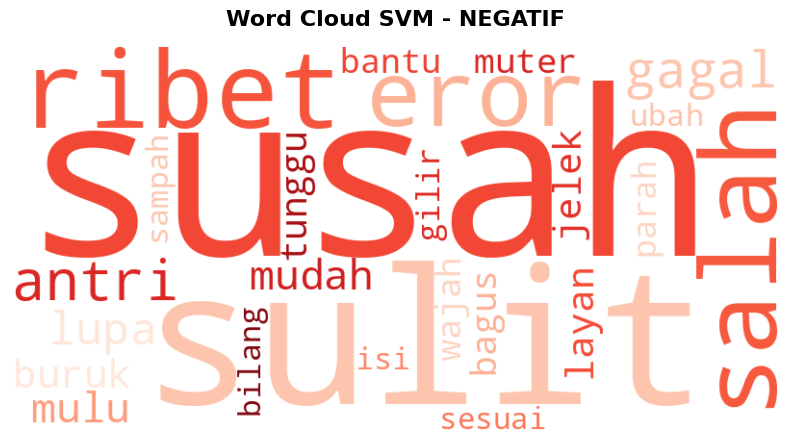

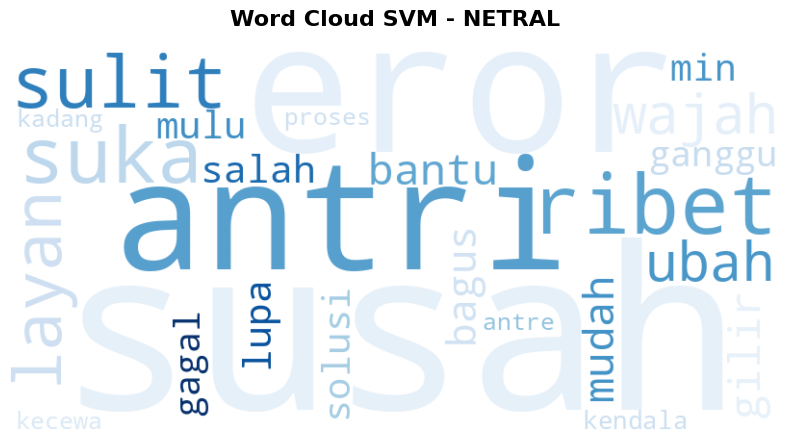

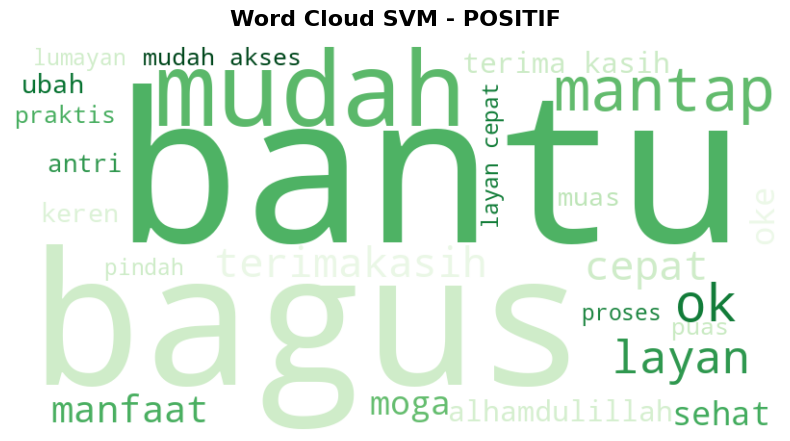


=== WORD CLOUD: HASIL PREDIKSI NAIVE BAYES ===


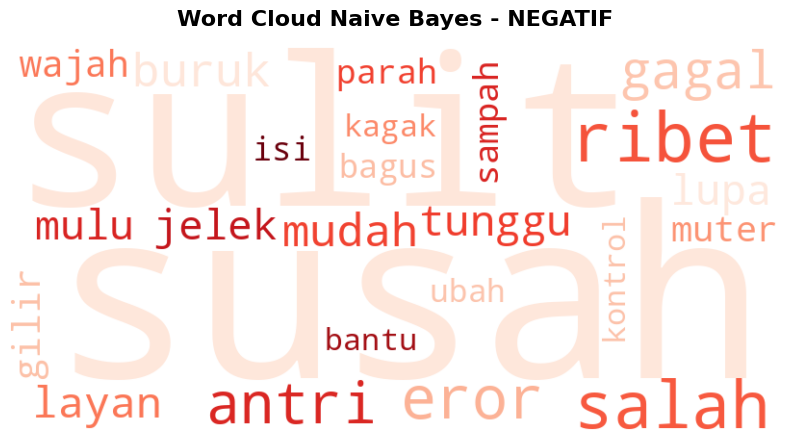

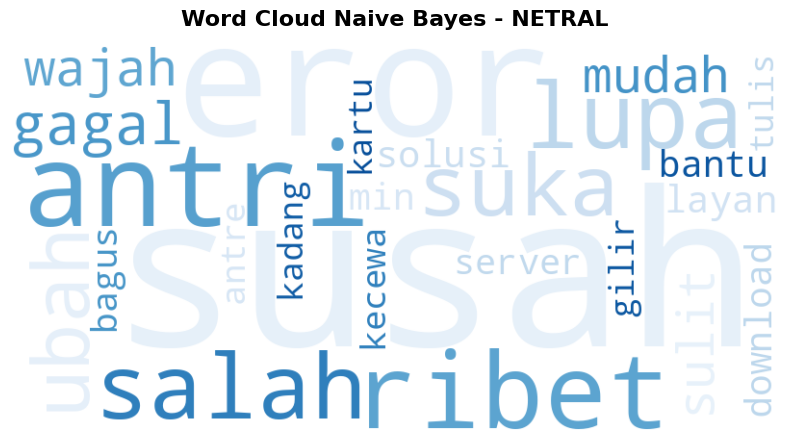

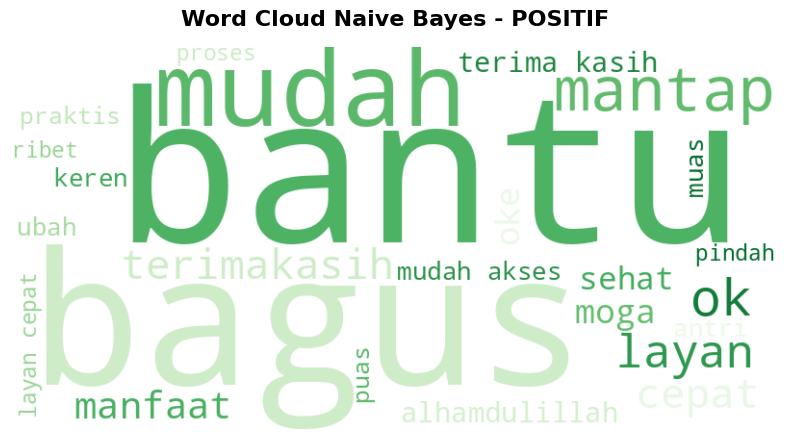

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def tampilkan_wordcloud_model(kolom_prediksi, label_sentimen, judul_plot, warna_peta):
    teks_filter = df_prediksi[df_prediksi[kolom_prediksi] == label_sentimen]['teks_preprocessing'].dropna().astype(str)

    gabungan_teks = ' '.join(teks_filter)

    if len(gabungan_teks.strip()) == 0:
        print(f"Tidak ada kata yang bisa ditampilkan untuk prediksi '{label_sentimen}' pada {kolom_prediksi}")
        return

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=warna_peta,
        max_words=25,
        random_state=42
    ).generate(gabungan_teks)

    # Menampilkan plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(judul_plot, fontsize=16, fontweight='bold', pad=15)
    plt.axis('off')
    plt.show()

print("=== WORD CLOUD: HASIL PREDIKSI SVM ===")
tampilkan_wordcloud_model('prediksi_svm', 'negatif', 'Word Cloud SVM - NEGATIF', 'Reds')
tampilkan_wordcloud_model('prediksi_svm', 'netral', 'Word Cloud SVM - NETRAL', 'Blues')
tampilkan_wordcloud_model('prediksi_svm', 'positif', 'Word Cloud SVM - POSITIF', 'Greens')

print("\n=== WORD CLOUD: HASIL PREDIKSI NAIVE BAYES ===")
tampilkan_wordcloud_model('prediksi_nb', 'negatif', 'Word Cloud Naive Bayes - NEGATIF', 'Reds')
tampilkan_wordcloud_model('prediksi_nb', 'netral', 'Word Cloud Naive Bayes - NETRAL', 'Blues')
tampilkan_wordcloud_model('prediksi_nb', 'positif', 'Word Cloud Naive Bayes - POSITIF', 'Greens')

In [ ]:
from collections import Counter
import pandas as pd

# ==========================================================
# FUNGSI UNTUK MENGAMBIL TOP KATA DALAM BENTUK LIST
# ==========================================================
def dapatkan_list_kata_sentimen(kolom_prediksi, label_sentimen, top_n=25):
    # Filter data teks berdasarkan kolom algoritma yang dipilih
    teks_filter = df_prediksi[df_prediksi[kolom_prediksi] == label_sentimen]['teks_preprocessing'].dropna().astype(str)

    # Gabungkan semua baris dan pecah menjadi satu list kata besar
    gabungan_kata = ' '.join(teks_filter).split()

    # Hitung frekuensi kemunculan tiap kata
    hitung_kata = Counter(gabungan_kata)

    # Ambil top_n kata yang paling sering muncul (berupa tuple: (kata, frekuensi))
    kata_terbanyak = hitung_kata.most_common(top_n)

    # Ekstrak katanya saja (tanpa angka frekuensinya) ke dalam sebuah List
    list_kata_saja = [kata for kata, frekuensi in kata_terbanyak]

    return list_kata_saja

# ==========================================================
# EKSEKUSI DAN MENAMPILKAN HASIL LIST
# ==========================================================

print("==================================================")
print("===       LIST TOP 25 KATA PREDIKSI SVM        ===")
print("==================================================")
list_svm_negatif = dapatkan_list_kata_sentimen('prediksi_svm', 'negatif', top_n=55)
list_svm_netral  = dapatkan_list_kata_sentimen('prediksi_svm', 'netral', top_n=55)
list_svm_positif = dapatkan_list_kata_sentimen('prediksi_svm', 'positif', top_n=55)

print("🔴 SVM Negatif (25 Kata):\n", list_svm_negatif)
print("\n🔵 SVM Netral (25 Kata):\n", list_svm_netral)
print("\n🟢 SVM Positif (25 Kata):\n", list_svm_positif)


print("\n==================================================")
print("===   LIST TOP 25 KATA PREDIKSI NAIVE BAYES    ===")
print("==================================================")
list_nb_negatif = dapatkan_list_kata_sentimen('prediksi_nb', 'negatif', top_n=55)
list_nb_netral  = dapatkan_list_kata_sentimen('prediksi_nb', 'netral', top_n=55)
list_nb_positif = dapatkan_list_kata_sentimen('prediksi_nb', 'positif', top_n=55)

print("🔴 Naive Bayes Negatif (25 Kata):\n", list_nb_negatif)
print("\n🔵 Naive Bayes Netral (25 Kata):\n", list_nb_netral)
print("\n🟢 Naive Bayes Positif (25 Kata):\n", list_nb_positif)

===       LIST TOP 25 KATA PREDIKSI SVM        ===
🔴 SVM Negatif (25 Kata):
 ['susah', 'sulit', 'ribet', 'salah', 'eror', 'antri', 'gagal', 'mudah', 'lupa', 'mulu', 'bagus', 'buruk', 'layan', 'tunggu', 'wajah', 'jelek', 'muter', 'bantu', 'parah', 'gilir', 'ubah', 'isi', 'bilang', 'sampah', 'internet', 'rujuk', 'lancar', 'sesuai', 'kasih', 'terang', 'tau', 'antre', 'kagak', 'kontrol', 'tulis', 'wifi', 'habis', 'repot', 'biar', 'busuk', 'mending', 'hapus', 'sinyal', 'ganggu', 'tolol', 'niat', 'klik', 'ktp', 'telepon', 'download', 'payah', 'ampun', 'proses', 'kemarin', 'koneksi']

🔵 SVM Netral (25 Kata):
 ['susah', 'eror', 'antri', 'ribet', 'suka', 'sulit', 'layan', 'wajah', 'ubah', 'bantu', 'gilir', 'salah', 'mudah', 'bagus', 'lupa', 'mulu', 'solusi', 'min', 'ganggu', 'gagal', 'kendala', 'kadang', 'antre', 'proses', 'kecewa', 'server', 'gimana', 'pilih', 'download', 'nama', 'tanggal', 'kasih', 'isi', 'tingkat', 'kontrol', 'aman', 'android', 'diupdate', 'riwayat', 'kartu', 'ku', 'periksa'

# ujicoba potongan program


In [ ]:
import math

# Hitung TF (Term Frequency)
tf_data = []
for index, row in df.iterrows():
    words = row['hasil_preprocessing'].split()
    word_freq = {}
    for word in words:
        word_freq[word] = word_freq.get(word, 0) + 1
    for word, freq in word_freq.items():
        tf_data.append({"term": word, "tf": freq, "dokumen_id": index})

# Hitung IDF (Inverse Document Frequency)
N = len(df)
idf_df = tf_df[["term","dokumen_id"]].drop_duplicates().groupby("term").count().reset_index()
idf_df.columns = ["term", "df"]
idf_df["idf"] = idf_df["df"].apply(lambda x: math.log(N / x))

# Hitung TF-IDF
tfidf_df["tf_idf"] = tfidf_df["tf"] * tfidf_df["idf"]
tfidf_df.to_csv('hasil_tfidf_jkn.csv', index=False, encoding='utf-8-sig')


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv('data_berlabel_jkn_uji_01.csv')
df = df.dropna(subset=['hasil_preprocessing'])

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 1))
X = tfidf.fit_transform(df['hasil_preprocessing'])

print(f"Bentuk Matriks TF-IDF: {X.shape}")
# Output: Bentuk Matriks TF-IDF: (19318, 9035)
# Artinya: 19318 ulasan dan 9035 kata unik (fitur)


In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split data 80% latih, 20% uji (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Distribusi Kelas Latih SEBELUM SMOTE:")
print(y_train.value_counts())

# Terapkan SMOTE hanya pada data latih
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribusi Kelas Latih SESUDAH SMOTE:")
print(pd.Series(y_train_res).value_counts())



In [ ]:
# SVM kombinasi SMOTE + Balanced Weight
svm_model = LinearSVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train_res, y_train_res)

# Prediksi data uji
svm_pred = svm_model.predict(X_test)

# Evaluasi model SVM
print("================ SVM + SMOTE ========================")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))


In [ ]:
# Naive Bayes data imbalance
nb_model = ComplementNB()
nb_model.fit(X_train_res, y_train_res)

# Prediksi data uji
nb_pred = nb_model.predict(X_test)

# Evaluasi model Naive Bayes
print("================ COMPLEMENT NAIVE BAYES ================")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, nb_pred))


In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def tampilkan_wordcloud_model(kolom_prediksi, label_sentimen, judul_plot, warna_peta):
    teks_filter = df_prediksi[df_prediksi[kolom_prediksi] == label_sentimen]\
                             ['teks_preprocessing'].dropna().astype(str)
    gabungan_teks = ' '.join(teks_filter)

    if len(gabungan_teks.strip()) == 0:
        print(f"Tidak ada kata untuk prediksi '{label_sentimen}'")
        return

    wordcloud = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=warna_peta,
        max_words=25,
        random_state=42
    ).generate(gabungan_teks)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(judul_plot, fontsize=16, fontweight="bold", pad=15)
    plt.axis('off')
    plt.show()


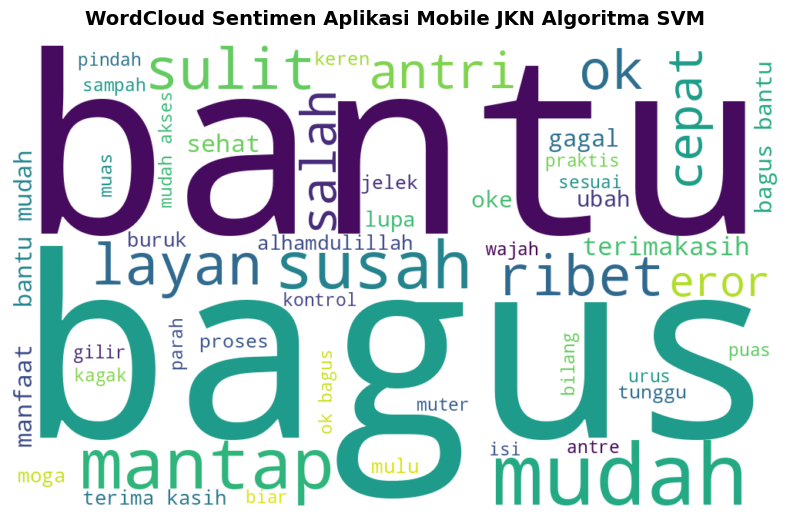

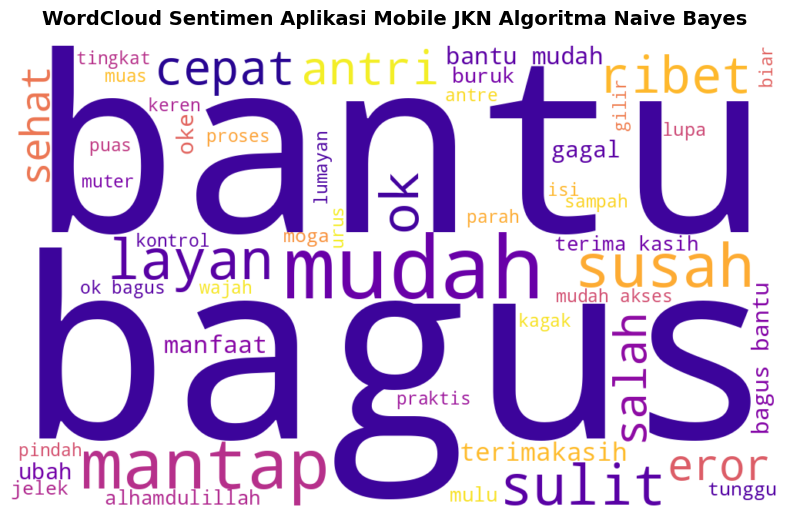

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

df_prediksi = pd.DataFrame()
df_prediksi['teks_preprocessing'] = df.loc[y_test.index, 'hasil_preprocessing']
df_prediksi['sentimen_asli'] = y_test
df_prediksi['prediksi_nb'] = nb_pred
df_prediksi['prediksi_svm'] = svm_pred

teks_akurat_svm = ' '.join(df_prediksi[df_prediksi['prediksi_svm'] == df_prediksi['sentimen_asli']]['teks_preprocessing'].dropna().astype(str))
teks_akurat_nb = ' '.join(df_prediksi[df_prediksi['prediksi_nb'] == df_prediksi['sentimen_asli']]['teks_preprocessing'].dropna().astype(str))

if len(teks_akurat_svm.strip()) > 0:
    wordcloud_svm = WordCloud(
        width=1000, height=600, background_color='white',
        colormap='viridis', max_words=50, random_state=42
    ).generate(teks_akurat_svm)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud_svm, interpolation='bilinear')
    plt.title('WordCloud Sentimen Aplikasi Mobile JKN Algoritma SVM', fontsize=14, fontweight='bold', pad=15)
    plt.axis('off')
    plt.savefig('hasil_wordcloud_svm.png', dpi=300, bbox_inches='tight')
    plt.show()

if len(teks_akurat_nb.strip()) > 0:
    wordcloud_nb = WordCloud(
        width=1000, height=600, background_color='white',
        colormap='plasma', max_words=50, random_state=42
    ).generate(teks_akurat_nb)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud_nb, interpolation='bilinear')
    plt.title('WordCloud Sentimen Aplikasi Mobile JKN Algoritma Naive Bayes', fontsize=14, fontweight='bold', pad=15)
    plt.axis('off')
    plt.savefig('hasil_wordcloud_nb.png', dpi=300, bbox_inches='tight')
    plt.show()